# Semantic Role Labeling (SRL) with LangGraph

## Theory

**Semantic Role Labeling (SRL)** answers the question:
*Who did what to whom, where, when, why, and how?*

It assigns semantic roles to every phrase in a sentence relative to its predicate (verb).

### Core role inventory (PropBank standard)

| Role | Name | Question it answers | Example |
|---|---|---|---|
| ARG0 | Agent | Who performed the action? | *The chef* cooked |
| ARG1 | Patient / Theme | What was acted upon? | cooked *a meal* |
| ARG2 | Beneficiary / Instrument | For whom / with what? | cooked *for his family* |
| ARGM-LOC | Location | Where? | cooked *in the kitchen* |
| ARGM-TMP | Time | When? | cooked *yesterday* |
| ARGM-MNR | Manner | How? | cooked *carefully* |
| ARGM-PRP | Purpose | Why? | cooked *to celebrate* |
| ARGM-NEG | Negation | Is it negated? | *did not* cook |
| ARGM-CAU | Cause | Because of what? | cooked *because of hunger* |

### SRL vs syntactic parsing

| Syntactic parse | SRL |
|---|---|
| Finds grammatical structure | Finds meaning structure |
| Subject / object / modifier | Agent / patient / location |
| *The chef* = subject | *The chef* = ARG0 (agent) |
| Language-specific | Language-independent concept |

### Real-world applications
- Information extraction from news / legal / medical text
- Question answering (who did what)
- Knowledge graph construction
- Event detection in financial documents
- Summarisation with preserved roles

### LangGraph pipeline
```
sentence
  → detect_predicates     (find all verbs)
  → label_arguments       (assign ARG0/1/2/ARGM roles per predicate)
  → resolve_coreference   (link 'he/she/it/they' to their referents)
  → build_semantic_frame  (compose final structured event frames)
  → SRL report
```
Each node has one job. The state accumulates as the pipeline progresses.

In [1]:
# ── Imports ───────────────────────────────────────────────
from typing import TypedDict, Optional, List
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import json, os

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

llm = ChatOpenAI(model="gpt-4o", temperature=0.0)  # temp=0 for deterministic NLP

In [2]:
# ── State ─────────────────────────────────────────────────
# SRLState accumulates analysis results across all four nodes.
# Every field is written by exactly one node and read by downstream nodes.

class SRLState(TypedDict):
    # Input
    sentence: str                       # Raw input sentence

    # Step 1 output
    predicates: Optional[List[dict]]    # [{verb, position, tense, voice}]

    # Step 2 output
    labeled_roles: Optional[List[dict]] # [{predicate, ARG0, ARG1, ARG2, modifiers{}}]

    # Step 3 output
    resolved_roles: Optional[List[dict]]# Same as above but pronouns replaced

    # Step 4 output
    frames: Optional[List[dict]]        # Clean semantic event frames
    srl_report: Optional[str]           # Human-readable final report

In [3]:
# ── Helper: safe JSON parse ───────────────────────────────
def parse_json(text: str) -> any:
    """Strip markdown fences and parse JSON safely."""
    clean = text.strip()
    if clean.startswith("```"):
        lines = clean.split("\n")
        clean = "\n".join(lines[1:-1])
    return json.loads(clean)

In [4]:
# ── Node 1: detect_predicates ─────────────────────────────
# SINGLE JOB: Find every predicate (main verb) in the sentence.
#
# A sentence can have multiple predicates:
#   "She bought milk and then drove home"
#   → predicates: [bought, drove]
#
# Each predicate is the anchor for a separate SRL frame.
# We also capture tense and voice (active/passive) as they
# affect how ARG0 and ARG1 are interpreted.

def detect_predicates(state: SRLState) -> SRLState:
    print(f"\n[Node 1] Detecting predicates in: '{state['sentence']}'")

    prompt = """You are an NLP expert performing predicate detection.

Identify ALL main predicates (verbs that carry an event or state) in the sentence.
Exclude auxiliary verbs (is, was, has, will, would) UNLESS they are the main verb.

For each predicate output JSON with this schema:
{
  "predicates": [
    {
      "verb": "the verb lemma (base form)",
      "surface_form": "exact form as it appears in text",
      "tense": "past | present | future | perfect | progressive",
      "voice": "active | passive",
      "negated": true or false
    }
  ]
}

Reply with ONLY the JSON object. No explanation, no markdown fences.
"""

    response = llm.invoke([
        SystemMessage(content=prompt),
        HumanMessage(content=f"Sentence: {state['sentence']}")
    ])

    result = parse_json(response.content)
    predicates = result["predicates"]

    print(f"[Node 1] Found {len(predicates)} predicate(s): "
          f"{[p['verb'] for p in predicates]}")
    return {**state, "predicates": predicates}

In [5]:
# ── Node 2: label_arguments ───────────────────────────────
# SINGLE JOB: For each predicate, assign semantic roles to
# every argument phrase in the sentence.
#
# Role assignment rules (PropBank convention):
#   ARG0 = the doer / causer (typically the agent)
#   ARG1 = the thing directly affected or described
#   ARG2 = secondary object (beneficiary, instrument, destination)
#   ARGM-* = modifiers (location, time, manner, purpose, cause, negation)
#
# In passive sentences, ARG0 may be absent ("The meal was cooked")
# or appear in a by-phrase ("cooked BY the chef" → chef = ARG0).

def label_arguments(state: SRLState) -> SRLState:
    print(f"\n[Node 2] Labeling arguments for {len(state['predicates'])} predicate(s)")

    predicates_json = json.dumps(state["predicates"], indent=2)

    prompt = f"""You are an NLP expert performing Semantic Role Labeling (PropBank standard).

Original sentence: "{state['sentence']}"

Predicates already detected:
{predicates_json}

For EACH predicate, identify and label all argument phrases.

Role definitions:
- ARG0: Agent — who performs the action
- ARG1: Patient/Theme — what is directly acted on or described
- ARG2: Beneficiary/Instrument/Destination — secondary argument
- ARGM-LOC: Location (where)
- ARGM-TMP: Time (when)
- ARGM-MNR: Manner (how)
- ARGM-PRP: Purpose (in order to)
- ARGM-CAU: Cause (because)
- ARGM-NEG: Negation marker
- ARGM-EXT: Extent / degree

Output JSON:
{{
  "labeled_roles": [
    {{
      "predicate": "verb lemma",
      "ARG0": "exact phrase or null",
      "ARG1": "exact phrase or null",
      "ARG2": "exact phrase or null",
      "modifiers": {{
        "ARGM-LOC": "phrase or null",
        "ARGM-TMP": "phrase or null",
        "ARGM-MNR": "phrase or null",
        "ARGM-PRP": "phrase or null",
        "ARGM-CAU": "phrase or null",
        "ARGM-NEG": "phrase or null"
      }}
    }}
  ]
}}

Use null for roles that are absent. Do not invent arguments not present in the sentence.
Reply with ONLY the JSON. No explanation, no markdown fences.
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    result = parse_json(response.content)
    labeled = result["labeled_roles"]

    print(f"[Node 2] Labeled roles for: {[r['predicate'] for r in labeled]}")
    return {**state, "labeled_roles": labeled}

In [6]:
# ── Node 3: resolve_coreference ───────────────────────────
# SINGLE JOB: Replace pronouns and noun references in role
# slots with their actual referents from the sentence.
#
# Why this matters:
#   "John told Mary he would call her later."
#   ARG0 of 'call' is 'he' → must resolve to 'John'
#   ARG1 of 'call' is 'her' → must resolve to 'Mary'
#
# Without coreference resolution, downstream consumers of
# the SRL output get pronouns instead of real entities —
# making the frames useless for knowledge extraction.
#
# If no pronouns exist in the sentence, this node passes
# through unchanged (state copy with resolved = labeled).

def resolve_coreference(state: SRLState) -> SRLState:
    print(f"\n[Node 3] Resolving coreferences")

    labeled_json = json.dumps(state["labeled_roles"], indent=2)

    prompt = f"""You are an NLP expert performing coreference resolution.

Original sentence: "{state['sentence']}"

Labeled SRL roles (may contain pronouns like he/she/it/they/his/her/their):
{labeled_json}

Task: For any role slot that contains a pronoun or vague reference,
replace it with the actual noun or noun phrase it refers to from the sentence.

Rules:
- Only replace if you are CERTAIN of the referent from the sentence itself
- If ambiguous, keep the original pronoun
- If there are no pronouns, return the input unchanged
- Do NOT infer information not in the sentence

Return the updated labeled_roles list in the same JSON structure:
{{
  "resolved_roles": [ ...same structure as labeled_roles... ]
}}

Reply with ONLY the JSON. No explanation, no markdown fences.
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    result = parse_json(response.content)
    resolved = result["resolved_roles"]

    print(f"[Node 3] Coreference resolution complete")
    return {**state, "resolved_roles": resolved}

In [7]:
# ── Node 4: build_semantic_frame ──────────────────────────
# SINGLE JOB: Compose the final human-readable semantic frames
# and a summary report from the resolved roles.
#
# A semantic frame answers the 6 journalism questions:
#   WHO did WHAT to WHOM, WHERE, WHEN, HOW/WHY?
#
# This is the output node — it converts structured JSON
# into a format useful for downstream tasks like:
#   - Knowledge graph population
#   - Event timeline extraction
#   - Question answering
#   - Automated summarisation

def build_semantic_frame(state: SRLState) -> SRLState:
    print(f"\n[Node 4] Building semantic frames")

    resolved_json = json.dumps(state["resolved_roles"], indent=2)
    predicate_json = json.dumps(state["predicates"], indent=2)

    prompt = f"""You are an NLP expert building semantic event frames.

Original sentence: "{state['sentence']}"

Predicates:
{predicate_json}

Resolved SRL roles:
{resolved_json}

Task: Build a clean semantic frame for each predicate and a plain-English summary.

Output JSON:
{{
  "frames": [
    {{
      "event": "one-line description of what happened",
      "predicate": "verb lemma",
      "tense": "past/present/future/etc",
      "negated": true or false,
      "who": "ARG0 value or null",
      "did_what": "predicate + ARG1 combined naturally",
      "to_whom": "ARG2 beneficiary or null",
      "where": "ARGM-LOC or null",
      "when": "ARGM-TMP or null",
      "how": "ARGM-MNR or null",
      "why": "ARGM-PRP or ARGM-CAU or null",
      "full_roles": {{ ...copy of the resolved role dict for this predicate... }}
    }}
  ],
  "summary": "A 1-2 sentence plain English summary of all events in the sentence."
}}

Reply with ONLY the JSON. No explanation, no markdown fences.
"""

    response = llm.invoke([HumanMessage(content=prompt)])
    result = parse_json(response.content)

    frames  = result["frames"]
    summary = result["summary"]

    # Build human-readable report
    report_lines = [
        f"SRL ANALYSIS REPORT",
        f"=" * 50,
        f"Sentence : {state['sentence']}",
        f"Predicates: {len(frames)} event(s) found",
        f"",
    ]
    for i, frame in enumerate(frames, 1):
        report_lines.append(f"Event {i}: {frame['event']}")
        report_lines.append(f"  Predicate : {frame['predicate']} ({frame['tense']}{'  [NEGATED]' if frame['negated'] else ''})")
        if frame.get("who"):     report_lines.append(f"  WHO       : {frame['who']}")
        if frame.get("did_what"):report_lines.append(f"  DID WHAT  : {frame['did_what']}")
        if frame.get("to_whom"): report_lines.append(f"  TO WHOM   : {frame['to_whom']}")
        if frame.get("where"):   report_lines.append(f"  WHERE     : {frame['where']}")
        if frame.get("when"):    report_lines.append(f"  WHEN      : {frame['when']}")
        if frame.get("how"):     report_lines.append(f"  HOW       : {frame['how']}")
        if frame.get("why"):     report_lines.append(f"  WHY       : {frame['why']}")
        report_lines.append("")

    report_lines += [f"Summary: {summary}"]
    report = "\n".join(report_lines)

    print(f"[Node 4] Built {len(frames)} semantic frame(s)")
    return {**state, "frames": frames, "srl_report": report}

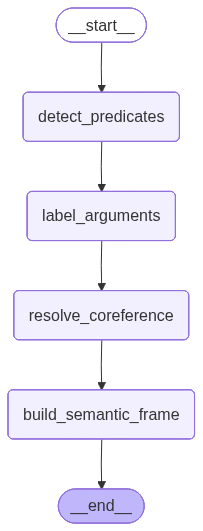

In [8]:
# ── Graph Construction ─────────────────────────────────────
def build_srl_graph():
    builder = StateGraph(SRLState)

    builder.add_node("detect_predicates",   detect_predicates)
    builder.add_node("label_arguments",     label_arguments)
    builder.add_node("resolve_coreference", resolve_coreference)
    builder.add_node("build_semantic_frame",build_semantic_frame)

    builder.add_edge(START,                  "detect_predicates")
    builder.add_edge("detect_predicates",    "label_arguments")
    builder.add_edge("label_arguments",      "resolve_coreference")
    builder.add_edge("resolve_coreference",  "build_semantic_frame")
    builder.add_edge("build_semantic_frame", END)

    return builder.compile()


graph = build_srl_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
# ── Helper: run and display ───────────────────────────────
def analyze(sentence: str) -> dict:
    result = graph.invoke({
        "sentence":       sentence,
        "predicates":     None,
        "labeled_roles":  None,
        "resolved_roles": None,
        "frames":         None,
        "srl_report":     None,
    })
    print("\n" + result["srl_report"])
    return result

In [10]:
# ── Test 1: Simple active sentence ───────────────────────
# Clear ARG0, ARG1, ARGM-LOC, ARGM-TMP, ARGM-PRP
r1 = analyze(
    "The chef carefully cooked a delicious meal in the kitchen yesterday for his family."
)


[Node 1] Detecting predicates in: 'The chef carefully cooked a delicious meal in the kitchen yesterday for his family.'
[Node 1] Found 1 predicate(s): ['cook']

[Node 2] Labeling arguments for 1 predicate(s)
[Node 2] Labeled roles for: ['cook']

[Node 3] Resolving coreferences
[Node 3] Coreference resolution complete

[Node 4] Building semantic frames
[Node 4] Built 1 semantic frame(s)

SRL ANALYSIS REPORT
Sentence : The chef carefully cooked a delicious meal in the kitchen yesterday for his family.
Predicates: 1 event(s) found

Event 1: The chef cooked a meal for his family.
  Predicate : cook (past)
  WHO       : The chef
  DID WHAT  : cooked a delicious meal
  TO WHOM   : for the chef's family
  WHERE     : in the kitchen
  WHEN      : yesterday
  HOW       : carefully

Summary: Yesterday, the chef carefully cooked a delicious meal in the kitchen for his family.


In [11]:
# ── Test 2: Passive sentence ─────────────────────────────
# ARG0 appears in by-phrase; ARG1 is the grammatical subject
r2 = analyze(
    "The contract was signed by the CEO in New York on Monday."
)


[Node 1] Detecting predicates in: 'The contract was signed by the CEO in New York on Monday.'
[Node 1] Found 1 predicate(s): ['sign']

[Node 2] Labeling arguments for 1 predicate(s)
[Node 2] Labeled roles for: ['sign']

[Node 3] Resolving coreferences
[Node 3] Coreference resolution complete

[Node 4] Building semantic frames
[Node 4] Built 1 semantic frame(s)

SRL ANALYSIS REPORT
Sentence : The contract was signed by the CEO in New York on Monday.
Predicates: 1 event(s) found

Event 1: The CEO signed a contract.
  Predicate : sign (past)
  WHO       : the CEO
  DID WHAT  : signed the contract
  WHERE     : in New York
  WHEN      : on Monday

Summary: The CEO signed the contract in New York on Monday.


In [12]:
# ── Test 3: Multiple predicates ───────────────────────────
# Two events in one sentence — two separate frames expected
r3 = analyze(
    "The police arrested the suspect at the airport and charged him with fraud."
)


[Node 1] Detecting predicates in: 'The police arrested the suspect at the airport and charged him with fraud.'
[Node 1] Found 2 predicate(s): ['arrest', 'charge']

[Node 2] Labeling arguments for 2 predicate(s)
[Node 2] Labeled roles for: ['arrest', 'charge']

[Node 3] Resolving coreferences
[Node 3] Coreference resolution complete

[Node 4] Building semantic frames
[Node 4] Built 2 semantic frame(s)

SRL ANALYSIS REPORT
Sentence : The police arrested the suspect at the airport and charged him with fraud.
Predicates: 2 event(s) found

Event 1: The police arrested someone.
  Predicate : arrest (past)
  WHO       : The police
  DID WHAT  : arrested the suspect
  WHERE     : at the airport

Event 2: The police charged someone with a crime.
  Predicate : charge (past)
  WHO       : The police
  DID WHAT  : charged the suspect
  TO WHOM   : with fraud

Summary: The police arrested a suspect at the airport and charged him with fraud.


In [13]:
# ── Test 4: Negated predicate + coreference ───────────────
# 'he' must resolve to 'the manager'
r4 = analyze(
    "The manager did not approve the proposal because he believed it was too risky."
)


[Node 1] Detecting predicates in: 'The manager did not approve the proposal because he believed it was too risky.'
[Node 1] Found 2 predicate(s): ['approve', 'believe']

[Node 2] Labeling arguments for 2 predicate(s)
[Node 2] Labeled roles for: ['approve', 'believe']

[Node 3] Resolving coreferences
[Node 3] Coreference resolution complete

[Node 4] Building semantic frames
[Node 4] Built 2 semantic frame(s)

SRL ANALYSIS REPORT
Sentence : The manager did not approve the proposal because he believed it was too risky.
Predicates: 2 event(s) found

Event 1: The manager did not approve the proposal.
  Predicate : approve (past  [NEGATED])
  WHO       : The manager
  DID WHAT  : approve the proposal
  WHY       : because he believed it was too risky

Event 2: The manager believed the proposal was too risky.
  Predicate : believe (past)
  WHO       : The manager
  DID WHAT  : believed the proposal was too risky

Summary: The manager did not approve the proposal because he believed it was t

In [14]:
# ── Test 5: News-style sentence ───────────────────────────
# Real-world information extraction scenario
r5 = analyze(
    "Google acquired the startup for $2 billion to strengthen its AI capabilities."
)


[Node 1] Detecting predicates in: 'Google acquired the startup for $2 billion to strengthen its AI capabilities.'
[Node 1] Found 2 predicate(s): ['acquire', 'strengthen']

[Node 2] Labeling arguments for 2 predicate(s)
[Node 2] Labeled roles for: ['acquire', 'strengthen']

[Node 3] Resolving coreferences
[Node 3] Coreference resolution complete

[Node 4] Building semantic frames
[Node 4] Built 2 semantic frame(s)

SRL ANALYSIS REPORT
Sentence : Google acquired the startup for $2 billion to strengthen its AI capabilities.
Predicates: 2 event(s) found

Event 1: Google acquired a startup
  Predicate : acquire (past)
  WHO       : Google
  DID WHAT  : acquired the startup
  TO WHOM   : $2 billion
  WHY       : to strengthen Google's AI capabilities

Event 2: Google aims to strengthen its AI capabilities
  Predicate : strengthen (present)
  WHO       : Google
  DID WHAT  : strengthen Google's AI capabilities

Summary: Google acquired a startup for $2 billion to enhance its AI capabilities.

In [15]:
# ── Inspect raw JSON frames ───────────────────────────────
# The frames list is machine-readable for downstream use
# (knowledge graphs, event timelines, QA systems)

import json
print("Raw semantic frames (JSON):")
print(json.dumps(r5["frames"], indent=2))

Raw semantic frames (JSON):
[
  {
    "event": "Google acquired a startup",
    "predicate": "acquire",
    "tense": "past",
    "negated": false,
    "who": "Google",
    "did_what": "acquired the startup",
    "to_whom": "$2 billion",
    "where": null,
    "when": null,
    "how": null,
    "why": "to strengthen Google's AI capabilities",
    "full_roles": {
      "predicate": "acquire",
      "ARG0": "Google",
      "ARG1": "the startup",
      "ARG2": "$2 billion",
      "modifiers": {
        "ARGM-LOC": null,
        "ARGM-TMP": null,
        "ARGM-MNR": null,
        "ARGM-PRP": "to strengthen Google's AI capabilities",
        "ARGM-CAU": null,
        "ARGM-NEG": null
      }
    }
  },
  {
    "event": "Google aims to strengthen its AI capabilities",
    "predicate": "strengthen",
    "tense": "present",
    "negated": false,
    "who": "Google",
    "did_what": "strengthen Google's AI capabilities",
    "to_whom": null,
    "where": null,
    "when": null,
    "how": null,


In [16]:
# ── Inspect intermediate pipeline stages ─────────────────
# One of the key advantages of LangGraph: every step is inspectable

print("PREDICATES (Node 1 output):")
print(json.dumps(r5["predicates"], indent=2))

print("\nLABELED ROLES (Node 2 output):")
print(json.dumps(r5["labeled_roles"], indent=2))

print("\nRESOLVED ROLES (Node 3 output):")
print(json.dumps(r5["resolved_roles"], indent=2))

PREDICATES (Node 1 output):
[
  {
    "verb": "acquire",
    "surface_form": "acquired",
    "tense": "past",
    "voice": "active",
    "negated": false
  },
  {
    "verb": "strengthen",
    "surface_form": "strengthen",
    "tense": "present",
    "voice": "active",
    "negated": false
  }
]

LABELED ROLES (Node 2 output):
[
  {
    "predicate": "acquire",
    "ARG0": "Google",
    "ARG1": "the startup",
    "ARG2": "$2 billion",
    "modifiers": {
      "ARGM-LOC": null,
      "ARGM-TMP": null,
      "ARGM-MNR": null,
      "ARGM-PRP": "to strengthen its AI capabilities",
      "ARGM-CAU": null,
      "ARGM-NEG": null
    }
  },
  {
    "predicate": "strengthen",
    "ARG0": "Google",
    "ARG1": "its AI capabilities",
    "ARG2": null,
    "modifiers": {
      "ARGM-LOC": null,
      "ARGM-TMP": null,
      "ARGM-MNR": null,
      "ARGM-PRP": null,
      "ARGM-CAU": null,
      "ARGM-NEG": null
    }
  }
]

RESOLVED ROLES (Node 3 output):
[
  {
    "predicate": "acquire",
    "AR

## What each node does and why it's separate

| Node | Single job | Why separate |
|---|---|---|
| `detect_predicates` | Find verbs + tense + voice | Must know voice before assigning ARG0/ARG1 in passive |
| `label_arguments` | Assign PropBank roles | Purely structural — no entity resolution yet |
| `resolve_coreference` | Replace pronouns with referents | Keeps labeling clean; resolution is a distinct NLP task |
| `build_semantic_frame` | Format output for consumers | Presentation separated from analysis |

## Common SRL mistakes and how this pipeline avoids them

**Mistake 1 — ARG0 confusion in passive voice**
In *'The contract was signed by the CEO'*, a naive system marks
'the contract' as ARG0 (grammatical subject) instead of ARG1 (patient).
Node 1 detects voice=passive, so Node 2 correctly assigns:
ARG0 = 'the CEO' (by-phrase) and ARG1 = 'the contract'.

**Mistake 2 — Lost pronouns in multi-event sentences**
In *'The police arrested him and charged him'*, 'him' is meaningless
without resolution. Node 3 replaces both with 'the suspect'.

**Mistake 3 — Merging modifier types**
Time and location are both adverbials — a single-prompt system
often confuses them. Separate nodes with explicit role definitions
keep ARGM-TMP and ARGM-LOC distinct.

## Extending this pipeline

- Add a `detect_entities` node (NER) before `label_arguments` to type-check ARG0/ARG1 (PERSON, ORG, etc.)
- Add a `map_to_ontology` node after `build_semantic_frame` to align frames to FrameNet or VerbNet
- Add a `build_knowledge_triple` node to emit (subject, predicate, object) triples for a graph DB
- Process multiple sentences with a loop node to build a full event timeline